In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_excel("C:/Users/solan/Downloads/expectation_decider_dataset.xlsx")
data.head()

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,10,78,Yes,72,Pass
1,2,92,Yes,67,Fail
2,14,92,Yes,68,Pass
3,1,92,Yes,81,Pass
4,4,71,No,68,Fail


What is Probability?

Probability is the measure of how likely an event is to occur. Its value lies between 0 and 1.

Key Terms
Experiment → activity (exam result)
Event → outcome (pass/fail)
Sample Space → all outcomes
Probability → chance of event

                    P(A)=   Total outcomes
                        Number of favorable outcomes
	​


3 Examples from Dataset
Probability that a student passes
Probability that attendance > 80%
Probability that student studies > 10 hours

In [4]:
probability_pass = len(data[data["final_exam_pass"] == "Pass"]) / len(data)
probability_pass

0.57

In [7]:
pass_prob = (data["final_exam_pass"] == "Pass").mean()
print("P(Pass) =", pass_prob)

P(Pass) = 0.57


In [5]:
empirical = len(data[data["final_exam_pass"]=="Pass"]) / len(data)
print("Empirical Probability:", empirical)

Empirical Probability: 0.57


Theoretical

Based on assumption (example)

If pass depends on 3 conditions:

study > 8
attendance > 70
score > 50

Then probability = multiplication of individual probabilities

 Random Variable

Define:
X = number of students passing out of 3 randomly selected

Possible values:
X = 0, 1, 2, 3

Probability Table (Example)
X	P(X)
0	0.1
1	0.3
2	0.4
3	0.2
Mean & Variance
Mean = Σ X·P(X)
Variance = Σ (X-mean)²·P(X)

STEP 5: Random Variable (Binomial)

In [8]:
from scipy.stats import binom

n = 3
p = pass_prob

x = [0,1,2,3]
prob = [binom.pmf(i, n, p) for i in x]

dist = pd.DataFrame({"X": x, "P(X)": prob})
print(dist)

mean = n*p
variance = n*p*(1-p)

print("Mean:", mean)
print("Variance:", variance)

   X      P(X)
0  0  0.079507
1  1  0.316179
2  2  0.419121
3  3  0.185193
Mean: 1.71
Variance: 0.7353000000000001


Venn Diagram Data

In [9]:

A = data[data["study_hours"] > 10]
B = data[data["attendance"] > 90]

both = len(data[(data["study_hours"] > 10) & (data["attendance"] > 90)])

print("Study >10:", len(A))
print("Attendance >90:", len(B))
print("Both:", both)

Study >10: 108
Attendance >90: 41
Both: 20


In [13]:
table = pd.crosstab(data["group_discussion"], data["final_exam_pass"])
print(table)

final_exam_pass   Fail  Pass
group_discussion            
No                  53    39
Yes                 33    75


In [14]:
joint = table.loc["Yes","Pass"] / len(data)
print("Joint Probability:", joint)

Joint Probability: 0.375


In [15]:
marginal = table["Pass"].sum() / len(data)
print("Marginal Probability:", marginal)

Marginal Probability: 0.57


In [16]:
conditional = table.loc["Yes","Pass"] / table.loc["Yes"].sum()
print("Conditional Probability:", conditional)

Conditional Probability: 0.6944444444444444


Bayes Theorem

In [ ]:
P_H_given_P = 0.7
P_H_given_F = 0.4
P_H = 0.6

P_P = pass_prob
P_F = 1 - P_P

bayes = (P_H_given_P * P_P) / P_H
print("P(Pass | High Attendance):", bayes)

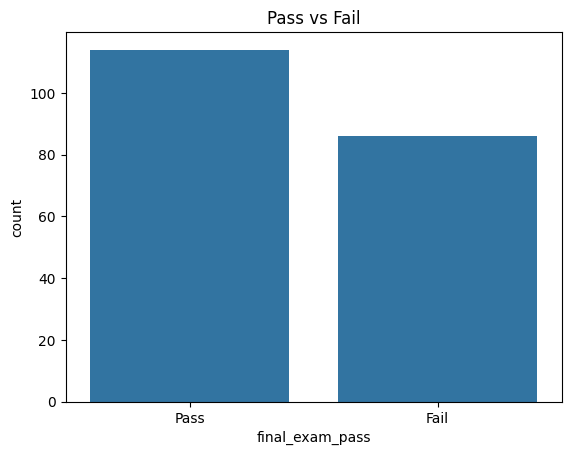

In [18]:
sns.countplot(x="final_exam_pass", data=data)
plt.title("Pass vs Fail")
plt.show()


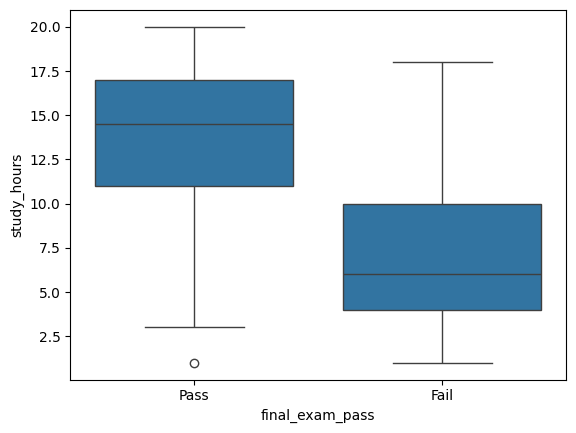

In [19]:
sns.boxplot(x="final_exam_pass", y="study_hours", data=data)
plt.show()

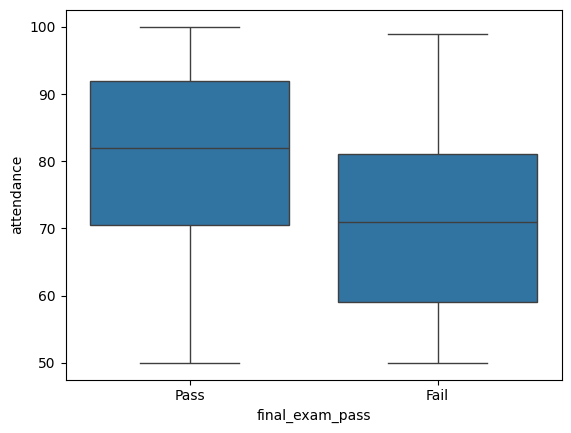

In [20]:
sns.boxplot(x="final_exam_pass", y="attendance", data=data)
plt.show()